# IoT Predictive Maintenance — Benchmark Analysis

This notebook provides a detailed dive into the model's performance on the **20% Benchmark Set** (data the model has never seen during training).

## Objectives
1. Load the trained Scikit-Learn Pipeline.
2. Visualize the extracted features.
3. Identify anomalies and analyze their physical characteristics.
4. Validate the 'Health Score' mapping logic.

In [15]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
DATA_PATH = r'D:\IOT Project\predictive-maintenance-ai\data\benchmark_20_of_half_a.csv'
MODEL_PATH = r'D:\IOT Project\predictive-maintenance-ai\models\fsl_heavy_motor_model.joblib'

print("✅ Libraries imported.")

✅ Libraries imported.


In [16]:
# Load data and model
df = pd.read_csv(DATA_PATH)
pipeline = joblib.load(MODEL_PATH)

sensor_cols = [c for c in df.columns if c not in ['timestamp', 'original_index']]

print(f"Dataset size: {df.shape}")
print(f"Features used: {len(sensor_cols)}")
df.head()

Dataset size: (524, 16)
Features used: 14


,fwd_rms_vel,fwd_mean,fwd_std,fwd_min,fwd_max,fwd_skew,fwd_kurtosis,rr_rms_vel,rr_mean,rr_std,rr_min,rr_max,rr_skew,rr_kurtosis,timestamp,original_index
0,2.896198,-0.000021,0.306270,-1.514509,1.348738,-0.070366,-0.000822,18.691389,0.000111,1.511033,-7.317019,5.564544,-0.303415,0.834462,2024-03-06T14:09:28.264000000,3410
1,4.856573,-0.000023,0.100727,-0.600975,0.369721,-0.345545,0.364530,14.264809,0.000005,1.368586,-7.013356,4.995192,-0.285478,0.961459,2024-02-28T06:49:35.996000000,2471
2,4.728652,0.000121,0.202644,-1.042666,0.697261,-0.280524,0.659603,21.085899,-0.000456,1.407295,-7.314685,5.395938,-0.329128,1.007096,2024-03-10T21:28:42.580000000,4599
3,4.628802,0.000031,0.099822,-0.545193,0.401083,-0.327992,0.327484,10.251646,0.000241,1.419238,-7.511623,5.437094,-0.311936,0.973907,2024-02-25T18:59:00.863000000,1563
4,4.794501,0.000035,0.099626,-0.578646,0.367630,-0.346275,0.361436,7.107842,-0.000159,1.370543,-7.185344,4.829309,-0.295208,0.963541,2024-02-29T02:40:03.456000000,2780


## 1. Feature Distribution
Let's look at the distribution of the primary health indicator: **Forward RMS Velocity**.

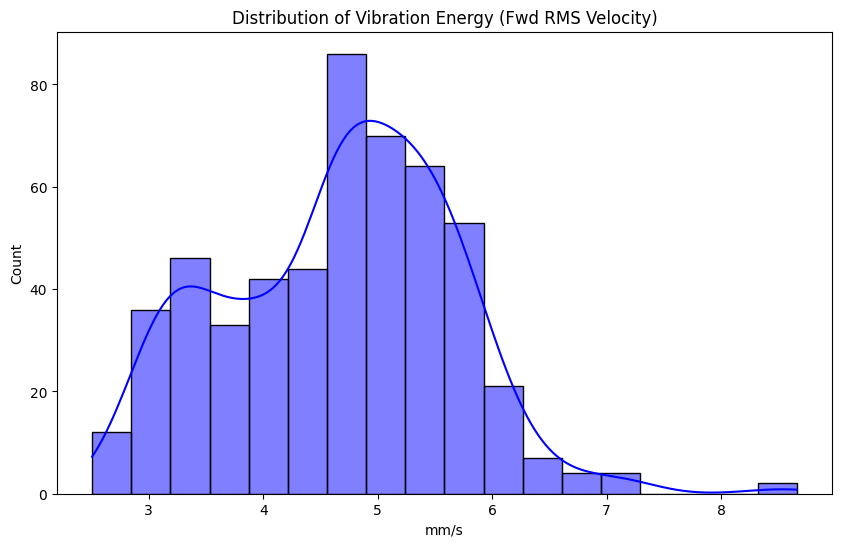

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fwd_rms_vel'], kde=True, color='blue')
plt.title("Distribution of Vibration Energy (Fwd RMS Velocity)")
plt.xlabel("mm/s")
plt.show()

## 2. Running Inference
We will now pass the benchmark data through the Isolation Forest.

In [18]:
# predict(): 1 for normal, -1 for anomaly
df['prediction'] = pipeline.predict(df[sensor_cols])
df['is_anomaly'] = df['prediction'] == -1

# decision_function(): Raw anomaly score (lower = more anomalous)
df['anomaly_score'] = pipeline.decision_function(df[sensor_cols])

# Map to 0-100 Health Index
df['health_index'] = np.clip((df['anomaly_score'] + 0.5) * 100, 0, 100)

print(f"Anomalies Detected: {df['is_anomaly'].sum()} out of {len(df)}")

Anomalies Detected: 24 out of 524


## 3. Visualizing the Decision
How does the model separate 'Normal' from 'Anomalous'?

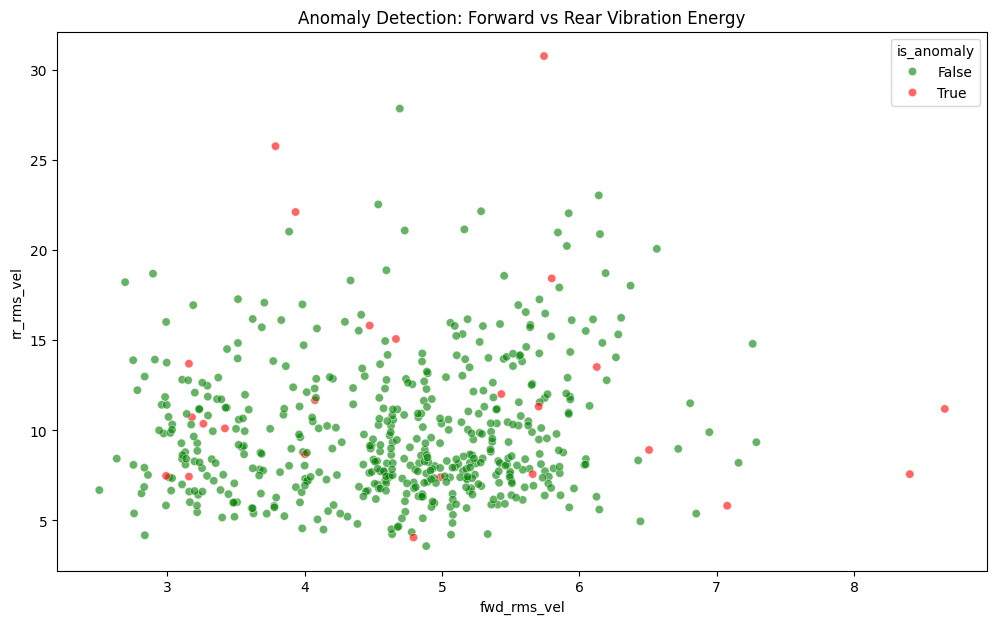

In [19]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='fwd_rms_vel', y='rr_rms_vel', hue='is_anomaly', palette={True: 'red', False: 'green'}, alpha=0.6)
plt.title("Anomaly Detection: Forward vs Rear Vibration Energy")
plt.show()

## 4. Deep Dive into Top Anomalies
Let's look at the samples with the **lowest Health Index**.

In [20]:
top_anomalies = df.sort_values('health_index').head(5)
print("Top 5 Critical Samples detected:")
top_anomalies[['health_index', 'fwd_rms_vel', 'fwd_kurtosis', 'rr_rms_vel', 'rr_kurtosis']]

Top 5 Critical Samples detected:


,health_index,fwd_rms_vel,fwd_kurtosis,rr_rms_vel,rr_kurtosis
99,36.878305,7.076368,0.112002,5.814704,0.847211
509,37.149282,3.263072,0.230916,10.361779,0.888218
471,37.226702,3.788093,6.684698,25.764185,1.036082
264,37.590095,4.002385,0.113213,8.674288,0.889289
138,38.258813,4.075108,0.188354,11.665052,2.030843


## 5. Correlation Heatmap
Which features tend to move together when a machine fails?

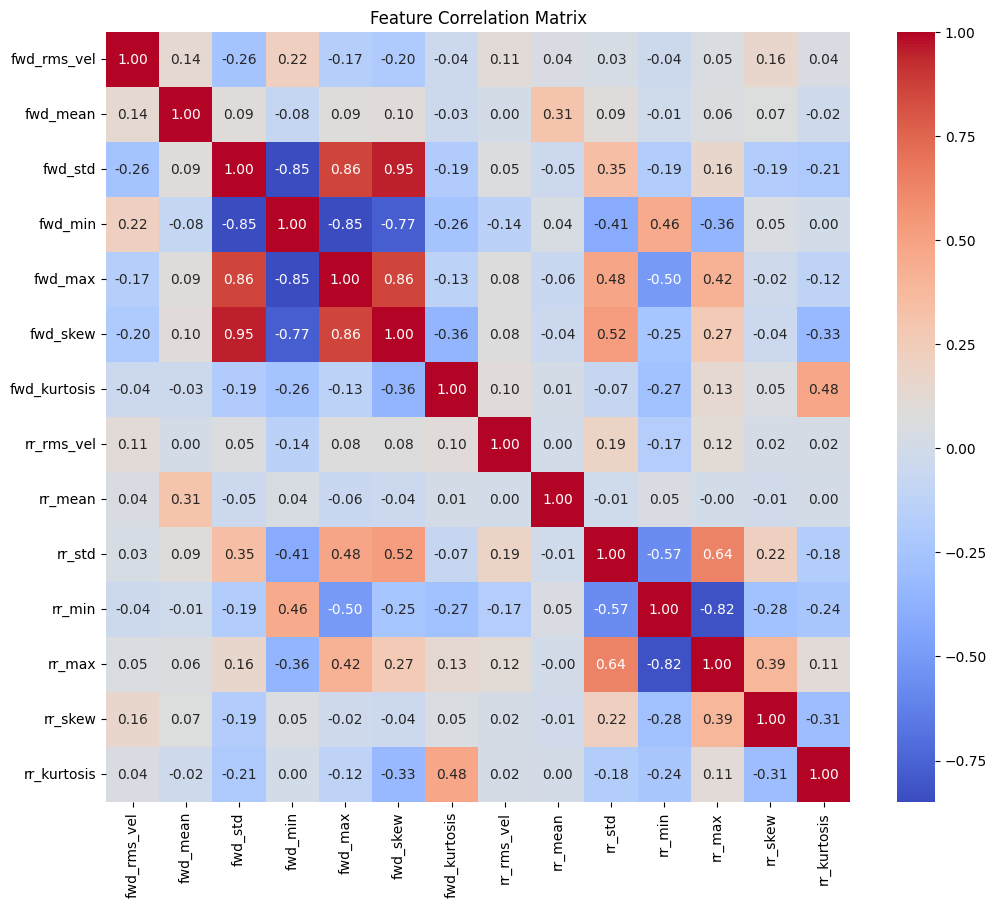

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[sensor_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

## Summary
The benchmark shows that the model successfully isolates samples that deviate from the standard vibration 'cluster'. 

**Observations:**
- Anomalies (red points) usually have higher RMS Velocity or higher Kurtosis.
- The 'Health Index' provides a smooth gradient for maintenance teams to prioritize work.